# Cointegration
In this session, we will assess whether a pair is cointegrated and the design a trading strategy based on the estimated spread

# Dependencies

In [304]:
import numpy as np
import pandas as pd

import statsmodels.api as sm
from statsmodels.tsa.stattools import coint
from statsmodels.regression.rolling import RollingOLS

import matplotlib.pyplot as plt

# Get data

You will need to time series of seemingly co-moving stocks 

Let Y be the first stock and Y the second 

In [305]:
df = pd.read_excel('Data 2.xlsx', sheet_name='GOOG_GOOGL', index_col=0, parse_dates=True)
df.head()
df.tail()

,GOOG US Equity,GOOGL US Equity
Date,,
2026-02-13,306.02,305.72
2026-02-17,302.82,302.02
2026-02-18,303.94,303.33
2026-02-19,303.56,302.85
2026-02-20,314.90,314.98


# Plot rolling correlation

<Axes: title={'center': 'Rolling Correlation'}, xlabel='Date'>

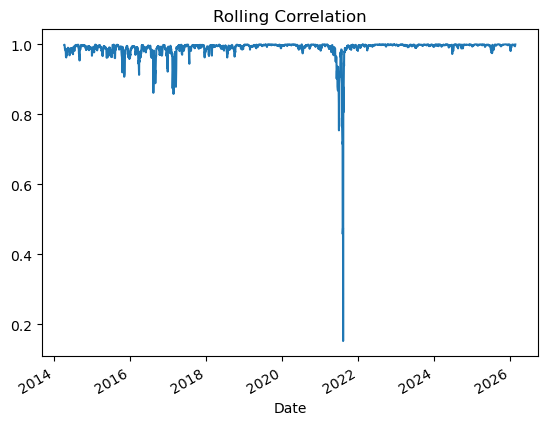

In [306]:
X = df['GOOG US Equity']
Y = df['GOOGL US Equity']

ret_X = X.pct_change().dropna()
ret_Y = Y.pct_change().dropna()

def correl_window(X, Y, window):
    return X.rolling(window).corr(Y)

rolling_corr = correl_window(ret_X, ret_Y, window=10)
rolling_corr.plot(title='Rolling Correlation')


# Cointegration test

### 1- Engle-Granger two step procedure

$H_0$: no cointegration (residual has unit root)

$H_1$: cointegration (residual is stationary)

a) OLS regression to estimate the residuals
$$y_t = \alpha + \beta X_t + u_t$$

b) Check the stationarity of the residuals


In [307]:
coint_t, p_value, crit_value = coint(X, Y)
print(f't-stat: {coint_t}')
print(f'p-value: {p_value}')
print(f'Critical values: {crit_value}')

t-stat: -3.2235995232728354
p-value: 0.06606905428979598
Critical values: [-3.90010291 -3.33817223 -3.04586734]


In [308]:
X_const = sm.add_constant(X)
model = sm.OLS(Y, X_const)
model_fit = model.fit()
print(model_fit.summary())

                            OLS Regression Results                            
Dep. Variable:        GOOGL US Equity   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 2.176e+07
Date:                Fri, 06 Mar 2026   Prob (F-statistic):               0.00
Time:                        12:05:15   Log-Likelihood:                -3337.6
No. Observations:                2994   AIC:                             6679.
Df Residuals:                    2992   BIC:                             6691.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.8599      0.024     36.

# Estimate and plot the spread
$$\hat s_t = y_t - \alpha - \hat \beta X_t$$

0.9892568828848297


C:\Users\Yassine Mannai\AppData\Local\Temp\ipykernel_17112\3509095534.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  alpha = model_fit.params[0]
C:\Users\Yassine Mannai\AppData\Local\Temp\ipykernel_17112\3509095534.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta = model_fit.params[1]


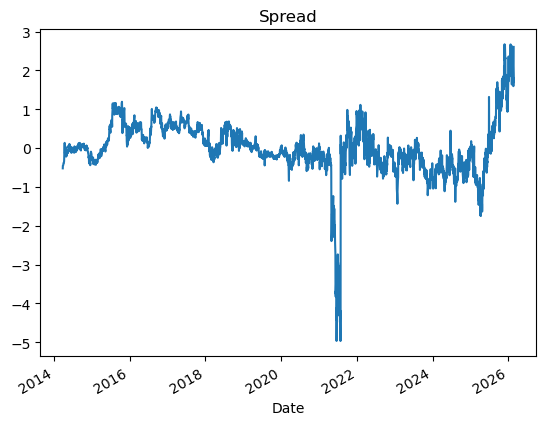

In [309]:
alpha = model_fit.params[0]
beta = model_fit.params[1]

spread = Y - alpha - beta * X 
spread.plot(title='Spread')
print(beta)

### Estimate the half life

Half life => La durée moyenne nécessaire pour que le spread revienne à la moitié de sa valeur de LT

$$s_t = \phi s_{t-1} + \epsilon _t$$


$$t_{1/2} = \frac{ln(2)}{-ln(\phi)} $$



In [310]:
spread_lag = spread.shift(1).dropna()
model = sm.OLS(spread[1:], spread_lag)
model_fit = model.fit()
print(model_fit.summary())

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.939
Model:                            OLS   Adj. R-squared (uncentered):              0.939
Method:                 Least Squares   F-statistic:                          4.602e+04
Date:                Fri, 06 Mar 2026   Prob (F-statistic):                        0.00
Time:                        12:05:15   Log-Likelihood:                          847.57
No. Observations:                2993   AIC:                                     -1693.
Df Residuals:                    2992   BIC:                                     -1687.
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [311]:
phi = model_fit.params[0] 
print(f'Phi: {phi:.4f}')  

half_life = -np.log(2) / np.log(phi)
print(f'Half-life: {half_life:.2f} days')   

Phi: 0.9709
Half-life: 23.50 days


C:\Users\Yassine Mannai\AppData\Local\Temp\ipykernel_17112\773755198.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  phi = model_fit.params[0]


# Design the trading strategy

**a. The intuition:**

If $\hat{s}_t > 0$: Long $y$, Short $\hat{\beta} x$

else if $\hat{s}_t < 0$: Short $y$, Long $\hat{\beta} x$

**b. Setting a threshold for $s_t$:**

$$
z_t = \frac{\mu - s_t}{\sigma}
$$

$z_t > 2$ : Long $y$, Short $\hat{\beta} x$

$z_t < -2$ : Short $y$, Long $\hat{\beta} x$

**c. Exit rule:**

Exit trade if $|z_t| < 0.5$

**d. Risk management:**

Exit trade if holding period $> 2 \times$ half-life

In [312]:
def backtest_strategy(spread, beta, half_life, window=int(2 * half_life), entry_z=2.0, exit_z=0.5):
    positions = pd.Series(0.0, index=spread.index)
    current_pos = 0
    entry_idx = None

    for i in range(window, len(spread)):
        spread_window = spread.iloc[i-window:i]
        mu = spread_window.mean()
        sigma = spread_window.std()
        z = (mu - spread.iloc[i]) / sigma

        long_signal = z >  entry_z
        short_signal = z < -entry_z
        exit_signal = abs(z) < exit_z

        # Exit
        if current_pos != 0:
            hold_days = i - entry_idx
            if exit_signal or hold_days > int(2 * half_life):
                current_pos = 0
                entry_idx = None

        # Entrée 
        if current_pos == 0:
            if long_signal:
                current_pos = 1    # achète Y, vend beta*X
                entry_idx = i
            elif short_signal:
                current_pos = -1    # vend Y, achète beta*X
                entry_idx = i

        positions.iloc[i] = current_pos

    ret_X = X.pct_change()
    ret_Y = Y.pct_change()
    wX = beta/(1+beta)
    wY = 1/(1+beta)

    daily_pnl = positions.shift(1) * (wY * ret_Y - wX * ret_X)
    cum_pnl =  (1 + daily_pnl).cumprod() -1

    return positions, daily_pnl, cum_pnl*100

positions, daily_pnl, cum_pnl = backtest_strategy(spread, beta, half_life)

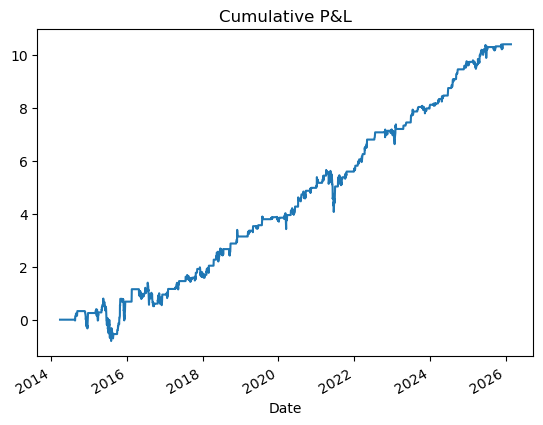

In [313]:
cum_pnl.plot(title='Cumulative P&L')
plt.show()

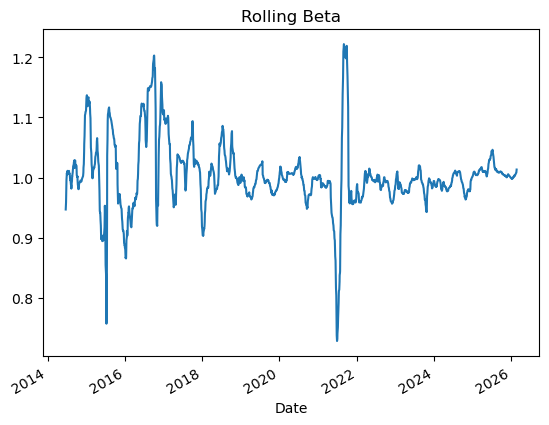

In [314]:
# Rolling beta 
def rolling_beta(X, Y, window):
    X_const = sm.add_constant(X)
    model = RollingOLS(Y, X_const, window=window)
    rres = model.fit()
    return rres.params['GOOG US Equity']    

window_beta = 60
rolling_beta_values = rolling_beta(X, Y, window=window_beta)
rolling_beta_values.plot(title='Rolling Beta')
plt.show()



In [315]:
# Rolling spread

In [316]:
# Test sur une autre paire